# 04 · Explainability, segment errors, fairness, and alert triage

A fraud model is only usable if an analyst can see **why** it flagged a transaction, and if the risk team can see **where** it fails and **who** bears its errors. This notebook covers:

1. Global importance: model-native (gain) and permutation.
2. SHAP: summary and dependence plots.
3. Local SHAP for three test cases: a true positive, a false positive and a missed fraud.
4. Partial dependence.
5. Segment-level error analysis: merchant category, amount band, age band and region.
6. Fairness, plus an ablation that adds age and gender back.
7. Alert triage bands and one sample case report.

> **Explanations describe the model, not the world.** A feature with a large SHAP value is one the model *relies on*. It does not show that the feature *causes* fraud. Night-time transactions are not fraudulent because of the hour. The simulator (and real fraudsters) simply tend to act then.

In [1]:
import sys, pathlib, json, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, shap
from IPython.display import display, Markdown
from sklearn.inspection import partial_dependence

from src import config, data, features, metrics, models, plotting, explain, triage
from src.regions import region
from src.plotting import takeaway

plotting.set_style()
pd.set_option("display.width", 200, "display.max_columns", 30, "display.float_format", "{:,.4f}".format)
rng = np.random.default_rng(config.SEED)

bundle = joblib.load(config.MODELS_DIR / "models.joblib")
LGB, FRAME, CATS = bundle["lgbm"], bundle["lgbm_frame"], bundle["categories"]
scores = features.add_derived(pd.read_parquet(config.DATA_PROCESSED / "scores.parquet"))
va, te = scores[scores.split == "validation"].reset_index(drop=True), scores[scores.split == "test"].reset_index(drop=True)
DAYS = {"validation": metrics.n_days(va.ts), "test": metrics.n_days(te.ts)}
decision = json.loads((config.REPORTS / "threshold_decision.json").read_text())
T_COST = decision["thresholds"]["Cost-minimising"]

def X_of(d, demographics=False):
    return features.onehot_frame(d, CATS, demographics) if FRAME == "onehot" else features.tree_frame(d, CATS, demographics)

X_va, X_te = X_of(va), X_of(te)
COLS = list(X_te.columns)
predict = lambda X: LGB.predict_proba(X)[:, 1]
assert np.allclose(predict(X_te), te["score_LightGBM"])      # the saved scores reproduce exactly
print(f"Model frame: {FRAME}; recommended (cost-minimising) threshold = {T_COST:.4f}")

Model frame: onehot; recommended (cost-minimising) threshold = 0.0084


## 1. Global importance: two views

- **Model-native (gain):** the total loss reduction from splits on each feature. It is cheap, but it favours features with many split points, and it describes training, not predictive value on new data.
- **Permutation (validation):** how much validation PR-AUC drops when a feature is shuffled. It measures predictive value on held-out data. One-hot category columns are shuffled **together** so every row stays a valid category.

When the two views disagree, the usual cause is correlated features (e.g. 24h spend vs 24h count). Permuting one leaves its partner to carry the signal.

In [2]:
groups = explain.feature_groups(COLS)
gain = pd.Series(LGB.booster_.feature_importance("gain"), index=LGB.booster_.feature_name())
gain.index = COLS
gain_g = pd.Series({g: gain[c].sum() for g, c in groups.items()})
gain_g = (gain_g / gain_g.sum()).sort_values(ascending=False)

sample = va.sample(150_000, random_state=config.SEED)
perm = explain.grouped_permutation_importance(predict, X_of(sample), sample.is_fraud, groups, n_repeats=3, seed=config.SEED)
imp = perm.merge(gain_g.rename("gain_share").reset_index().rename(columns={"index": "feature"}), on="feature")
imp.to_csv(config.REPORTS / "feature_importance.csv", index=False)
imp[["label", "pr_auc_drop", "pr_auc_drop_std", "gain_share"]]

,label,pr_auc_drop,pr_auc_drop_std,gain_share
0,Transaction amount (log),0.7204,0.0027,0.2156
1,Merchant category,0.5935,0.0086,0.0957
2,Card spend in prior 24h ($),0.1472,0.0072,0.2957
3,Night-time (22:00-04:00),0.0357,0.0013,0.1767
4,Amount / customer's historical average,0.0155,0.0012,0.1058
5,Hour of day,0.0123,0.0015,0.0059
6,Hours since card's previous transaction,0.0109,0.0009,0.0037
7,Card transactions in prior 24h,0.0105,0.0007,0.0130
8,Amount / customer's average in this category,0.0086,0.0014,0.0085
9,Amount / customer's 7-day average,0.0068,0.0004,0.0030


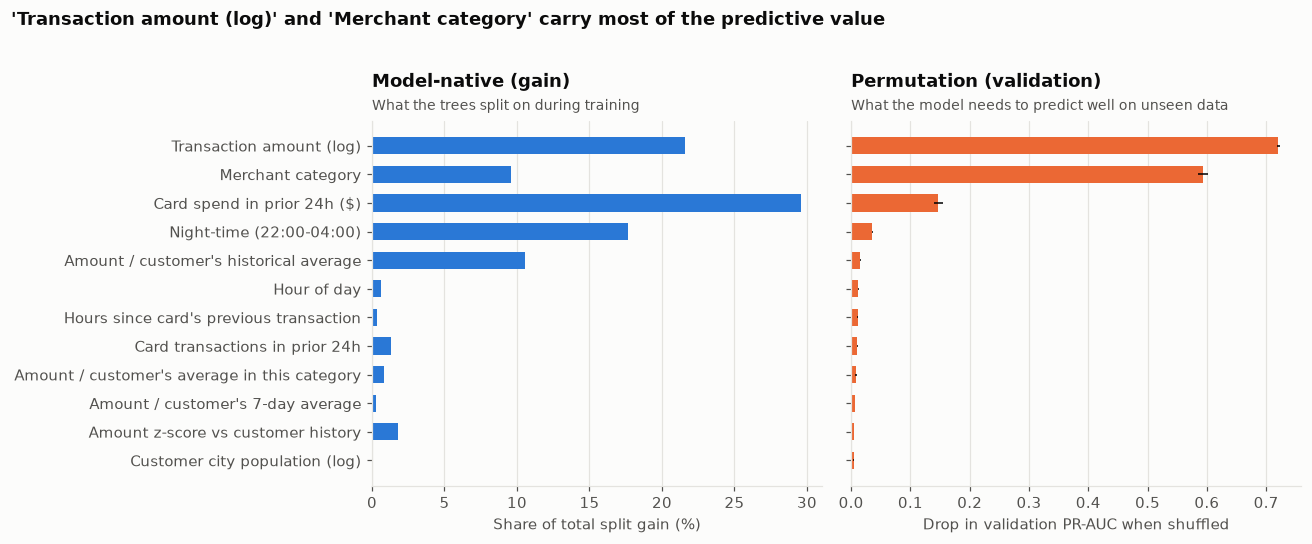

**Takeaway:** Shuffling 'Transaction amount (log)' drops validation PR-AUC by 0.720; the top 5 features by permutation are Transaction amount (log), Merchant category, Card spend in prior 24h ($), Night-time (22:00-04:00), Amount / customer's historical average. Features with near-zero permutation importance (Card transactions in prior 1h, First time at this merchant, Distance home to merchant (km), First time in this category) are candidates for removal in a simpler production model.

In [3]:
top = imp.head(12).iloc[::-1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
axes[0].barh(top.label, top.gain_share * 100, color=plotting.BLUE, height=0.6)
axes[0].set_xlabel("Share of total split gain (%)"); axes[0].grid(axis="y", visible=False)
plotting.title(axes[0], "Model-native (gain)", "What the trees split on during training")
axes[1].barh(top.label, top.pr_auc_drop, xerr=top.pr_auc_drop_std, color=plotting.ORANGE, height=0.6, error_kw=dict(lw=1))
axes[1].set_xlabel("Drop in validation PR-AUC when shuffled"); axes[1].grid(axis="y", visible=False)
plotting.title(axes[1], "Permutation (validation)", "What the model needs to predict well on unseen data")
fig.suptitle(f"'{imp.label.iloc[0]}' and '{imp.label.iloc[1]}' carry most of the predictive value",
             x=0.01, ha="left", fontweight="bold", y=1.02)
plotting.save(fig, "feature_importance"); plt.show()
takeaway(f"Shuffling '{imp.label.iloc[0]}' drops validation PR-AUC by {imp.pr_auc_drop.iloc[0]:.3f}; the top 5 features by permutation are "
         f"{', '.join(imp.label.head(5))}. Features with near-zero permutation importance ("
         f"{', '.join(imp[imp.pr_auc_drop < 0.001].label.head(4)) or 'none'}) are candidates for removal in a simpler production model.")

## 2. SHAP: global summary and dependence

TreeSHAP gives exact per-transaction contributions for tree ensembles. The SHAP sample is 20,000 random test transactions **plus every test fraud**. Frauds are oversampled so their explanations are visible in the plot, and the plot is not a picture of the base rate.

In [4]:
shap_idx = np.union1d(rng.choice(len(te), 20_000, replace=False), np.where(te.is_fraud == 1)[0])
Xs = X_te.iloc[shap_idx]
sv_raw, base_value = explain.shap_values(LGB, Xs)
sv, gcols = explain.group_onehot(sv_raw, COLS)
disp = te.iloc[shap_idx].reset_index(drop=True)
Xs_display = pd.DataFrame({c: (disp[c] if c != "category" else np.nan) for c in gcols})
glob = explain.global_importance(sv, gcols)
glob.to_csv(config.REPORTS / "shap_global_importance.csv", index=False)
print(f"SHAP rows: {len(shap_idx):,} (frauds: {int(disp.is_fraud.sum()):,}); base value (log-odds) = {base_value:.3f}")
glob.head(10)

SHAP rows: 21,287 (frauds: 1,358); base value (log-odds) = -10.666


,feature,mean_abs_shap,label
0,log_amt,1.3516,Transaction amount (log)
1,amt_sum_prior_24h,1.1975,Card spend in prior 24h ($)
2,is_night,1.0772,Night-time (22:00-04:00)
3,category,1.0357,Merchant category
4,cust_n_prior_txn,0.6920,Card history length (txns)
5,n_txn_prior_24h,0.5725,Card transactions in prior 24h
6,amt_to_cust_avg,0.4320,Amount / customer's historical average
7,amt_to_cust_category_avg,0.3932,Amount / customer's average in this category
8,hours_since_last_txn,0.3860,Hours since card's previous transaction
9,n_txn_prior_7d,0.3218,Card transactions in prior 7d


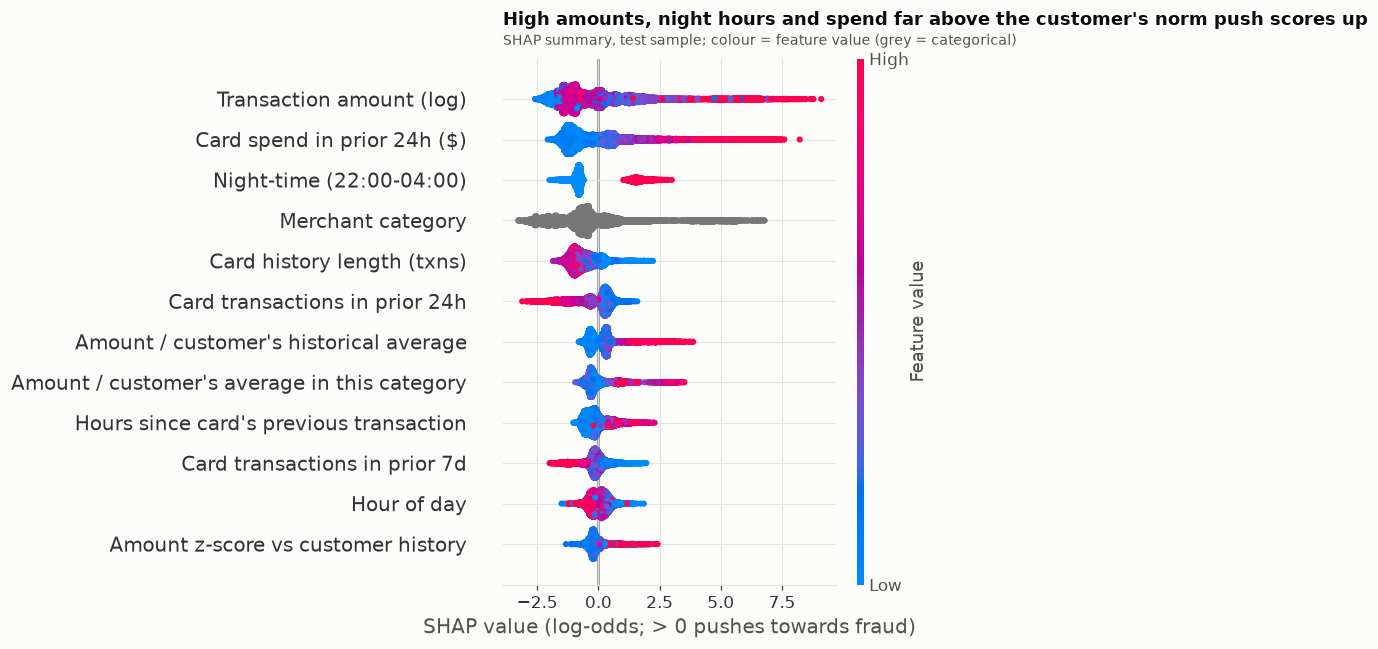

In [5]:
order = glob.feature.head(12).tolist()
plt.figure()
shap.summary_plot(sv[:, [gcols.index(f) for f in order]], Xs_display[order].astype(float),
                  feature_names=[explain.label(f) for f in order], show=False, max_display=12, plot_size=(9, 6))
ax = plt.gca()
ax.set_xlabel("SHAP value (log-odds; > 0 pushes towards fraud)")
plotting.title(ax, "High amounts, night hours and spend far above the customer's norm push scores up",
               "SHAP summary, test sample; colour = feature value (grey = categorical)")
plotting.save(plt.gcf(), "shap_summary"); plt.show()

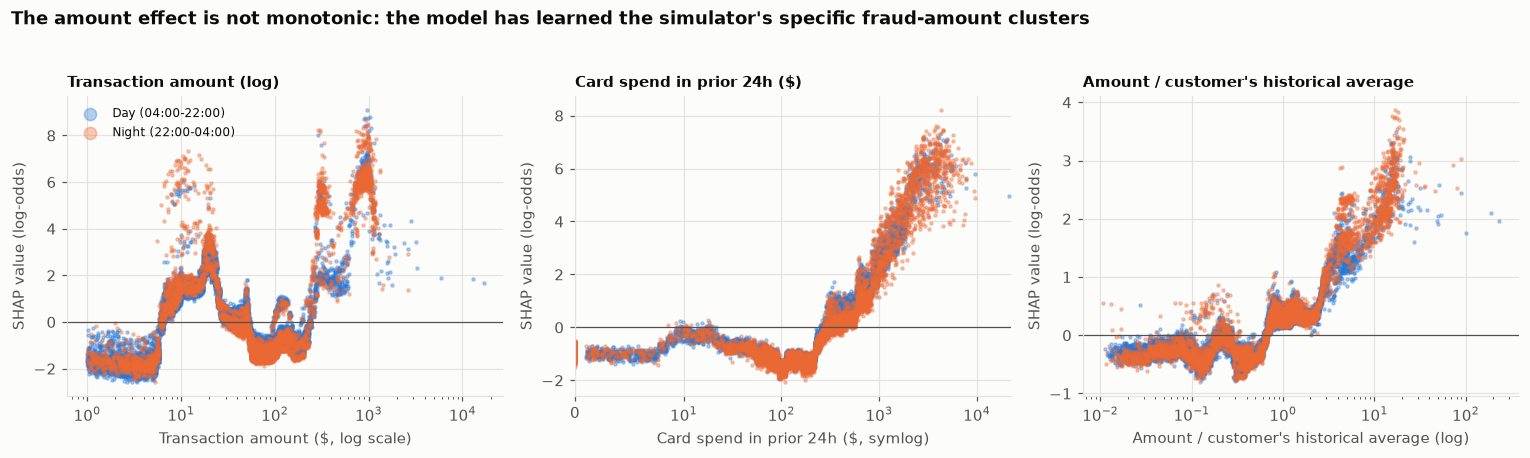

,mean SHAP of amount
"(0.0, 10.0]",-0.6395
"(10.0, 30.0]",1.7164
"(30.0, 100.0]",-0.7230
"(100.0, 250.0]",-0.7205
"(250.0, 1300.0]",4.6264
"(1300.0, inf]",3.0184


**Takeaway:** The amount's contribution peaks in two bands and drops in between. The model has memorised the amount ranges the Sparkov simulator uses for fraud, not a general 'bigger is riskier' rule. This is a red flag for real-world transfer and is discussed in the model-risk document.

In [6]:
dep = [("log_amt", "Transaction amount ($, log scale)", lambda v: np.expm1(v), "log"),
       ("amt_sum_prior_24h", "Card spend in prior 24h ($, symlog)", lambda v: v, "symlog"),
       ("amt_to_cust_avg", "Amount / customer's historical average (log)", lambda v: v, "log")]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (f, xlab, tf, scale) in zip(axes, dep):
    x = tf(disp[f].to_numpy(dtype=float)); y = sv[:, gcols.index(f)]
    night = disp.is_night.to_numpy() == 1
    ok = ~np.isnan(x)
    ax.scatter(x[ok & ~night], y[ok & ~night], s=4, alpha=0.35, color=plotting.BLUE, label="Day (04:00-22:00)", rasterized=True)
    ax.scatter(x[ok & night], y[ok & night], s=4, alpha=0.35, color=plotting.ORANGE, label="Night (22:00-04:00)", rasterized=True)
    ax.axhline(0, color=plotting.TEXT_2, lw=0.8)
    if scale == "symlog":
        ax.set_xscale("symlog", linthresh=10); ax.set_xlim(left=0)
    else:
        ax.set_xscale("log")
    ax.set_xlabel(xlab); ax.set_ylabel("SHAP value (log-odds)")
    ax.set_title(explain.label(f), loc="left", fontsize=10)
axes[0].legend(markerscale=4, loc="upper left", fontsize=8)
amt_x, amt_y = np.expm1(disp["log_amt"].to_numpy()), sv[:, gcols.index("log_amt")]
hi_bands = pd.Series(amt_y).groupby(pd.cut(amt_x, [0, 10, 30, 100, 250, 1300, np.inf])).mean()
fig.suptitle("The amount effect is not monotonic: the model has learned the simulator's specific fraud-amount clusters",
             x=0.01, ha="left", fontweight="bold", y=1.03)
plotting.save(fig, "shap_dependence"); plt.show()
display(hi_bands.rename("mean SHAP of amount").to_frame())
takeaway("The amount's contribution peaks in two bands and drops in between. The model has memorised the amount ranges the Sparkov "
         "simulator uses for fraud, not a general 'bigger is riskier' rule. This is a red flag for real-world transfer and is discussed in the model-risk document.")

## 3. Local explanations: a true positive, a false positive and a missed fraud

All three come from the **test** split, at the recommended cost-minimising threshold. They were picked by a fixed rule, not hand-picked:
- **True positive:** the fraud alert with the median score among true positives (a typical catch).
- **False positive:** the legitimate transaction with the highest score (the model's most confident mistake).
- **Missed fraud:** the fraud with the largest dollar amount that scored below the threshold (the costliest miss).

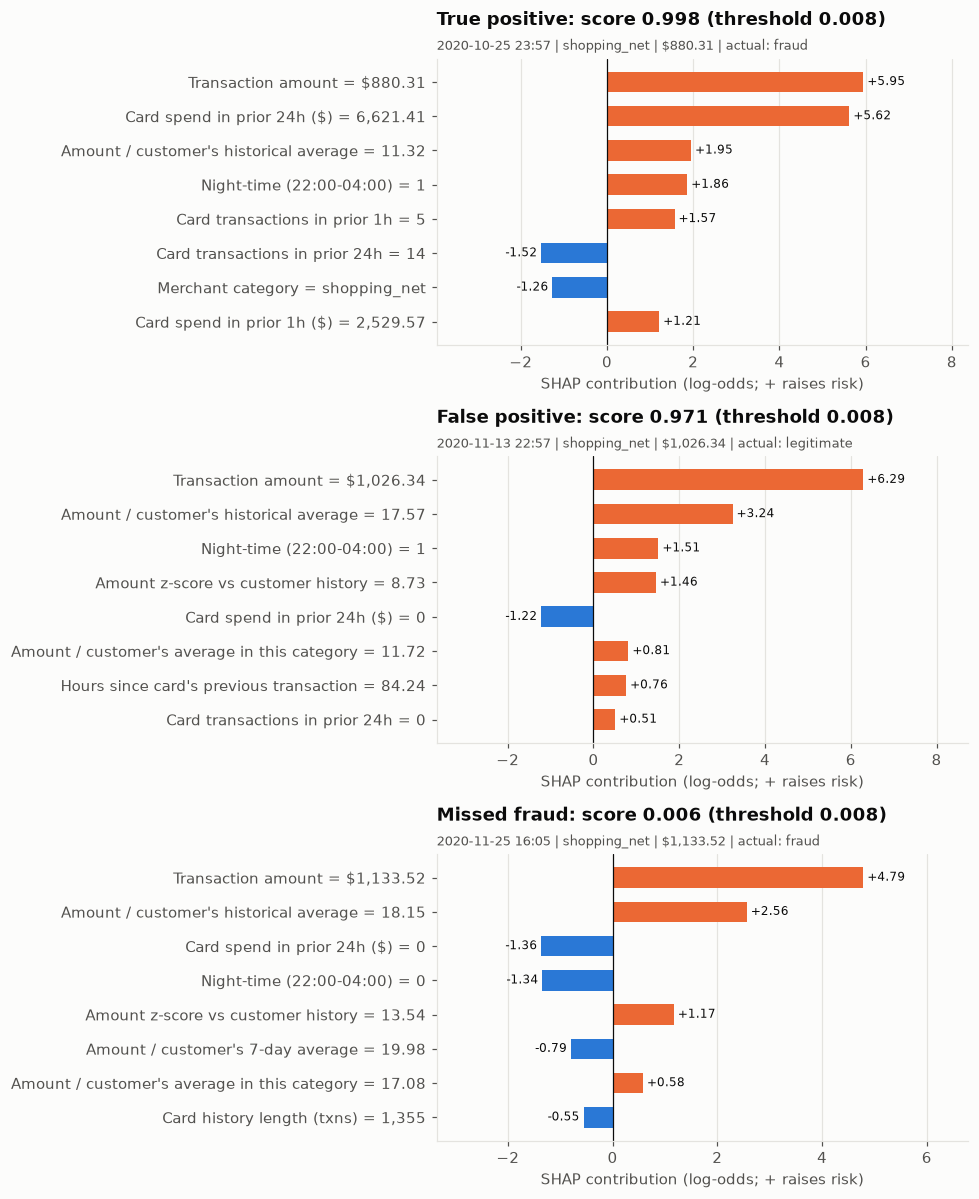

**True positive**

,feature,description,value,shap_log_odds,direction
0,log_amt,Transaction amount,$880.31,5.9473,raises risk
1,amt_sum_prior_24h,Card spend in prior 24h ($),"6,621.4100",5.6231,raises risk
2,amt_to_cust_avg,Amount / customer's historical average,11.3151,1.9506,raises risk
3,is_night,Night-time (22:00-04:00),1,1.8617,raises risk
4,n_txn_prior_1h,Card transactions in prior 1h,5,1.5664,raises risk
5,n_txn_prior_24h,Card transactions in prior 24h,14,-1.5229,lowers risk
6,category,Merchant category,shopping_net,-1.2642,lowers risk
7,amt_sum_prior_1h,Card spend in prior 1h ($),"2,529.5700",1.2112,raises risk


**False positive**

,feature,description,value,shap_log_odds,direction
0,log_amt,Transaction amount,"$1,026.34",6.2930,raises risk
1,amt_to_cust_avg,Amount / customer's historical average,17.5693,3.2432,raises risk
2,is_night,Night-time (22:00-04:00),1,1.5147,raises risk
3,amt_zscore_cust,Amount z-score vs customer history,8.7320,1.4573,raises risk
4,amt_sum_prior_24h,Card spend in prior 24h ($),0.0000,-1.2155,lowers risk
5,amt_to_cust_category_avg,Amount / customer's average in this category,11.7207,0.8145,raises risk
6,hours_since_last_txn,Hours since card's previous transaction,84.2442,0.7615,raises risk
7,n_txn_prior_24h,Card transactions in prior 24h,0,0.5091,raises risk


**Missed fraud**

,feature,description,value,shap_log_odds,direction
0,log_amt,Transaction amount,"$1,133.52",4.7888,raises risk
1,amt_to_cust_avg,Amount / customer's historical average,18.1538,2.5636,raises risk
2,amt_sum_prior_24h,Card spend in prior 24h ($),0.0000,-1.3599,lowers risk
3,is_night,Night-time (22:00-04:00),0,-1.3393,lowers risk
4,amt_zscore_cust,Amount z-score vs customer history,13.5402,1.1702,raises risk
5,amt_to_cust_avg_7d,Amount / customer's 7-day average,19.9827,-0.7921,lowers risk
6,amt_to_cust_category_avg,Amount / customer's average in this category,17.0833,0.5803,raises risk
7,cust_n_prior_txn,Card history length (txns),1355,-0.5526,lowers risk


In [7]:
te_alert = te.score_LightGBM >= T_COST
tp_pool = te[te_alert & (te.is_fraud == 1)].sort_values("score_LightGBM")
cases = {
    "True positive": tp_pool.index[len(tp_pool) // 2],
    "False positive": te[te_alert & (te.is_fraud == 0)].score_LightGBM.idxmax(),
    "Missed fraud": te[~te_alert & (te.is_fraud == 1)].amt.idxmax(),
}
case_sv_raw, _ = explain.shap_values(LGB, X_te.loc[list(cases.values())])
case_sv, _ = explain.group_onehot(case_sv_raw, COLS)
case_drivers = {}
fig, axes = plt.subplots(3, 1, figsize=(9, 11))
for ax, (name, i), row_sv in zip(axes, cases.items(), case_sv):
    row = te.loc[i]
    drv = explain.top_drivers(row_sv, gcols, explain.display_values(row), k=8)
    case_drivers[name] = drv
    explain.waterfall(ax, drv, base_value, row.score_LightGBM,
                      f"{name}: score {row.score_LightGBM:.3f} (threshold {T_COST:.3f})",
                      f"{row.ts:%Y-%m-%d %H:%M} | {row.category} | ${row.amt:,.2f} | actual: {'fraud' if row.is_fraud else 'legitimate'}",
                      plotting.ORANGE, plotting.BLUE, plotting.TEXT)
plotting.save(fig, "shap_local_cases"); plt.show()
for name, drv in case_drivers.items():
    display(Markdown(f"**{name}**")); display(drv)

In [8]:
fp = te.loc[cases["False positive"]]; fn = te.loc[cases["Missed fraud"]]
neg = case_drivers["Missed fraud"][case_drivers["Missed fraud"].shap_log_odds < 0].head(2)
takeaway(f"The false positive is a legitimate \${fp.amt:,.2f} {fp.category} transaction at {fp.ts:%H:%M} that looks like the fraud pattern "
         f"(top driver: {case_drivers['False positive'].description.iloc[0].lower()}). Only an analyst with extra context, such as customer contact or device data, can clear it. "
         f"The missed fraud (\${fn.amt:,.2f}, {fn.category}, {fn.ts:%H:%M}) scored {fn.score_LightGBM:.4f}, just under the threshold. What pulled it down: "
         + "; ".join(f"{d.description.lower()} = {explain._fmt(d.value)}" for d in neg.itertuples())
         + ". A large daytime purchase without a preceding spending burst doesn't fit the pattern the model learned.")

**Takeaway:** The false positive is a legitimate \$1,026.34 shopping_net transaction at 22:57 that looks like the fraud pattern (top driver: transaction amount). Only an analyst with extra context, such as customer contact or device data, can clear it. The missed fraud (\$1,133.52, shopping_net, 16:05) scored 0.0062, just under the threshold. What pulled it down: card spend in prior 24h ($) = 0; night-time (22:00-04:00) = 0. A large daytime purchase without a preceding spending burst doesn't fit the pattern the model learned.

## 4. Partial dependence (optional view)

Partial dependence averages the model's prediction over the data while one feature varies. It complements SHAP dependence plots, but it can mislead when features are correlated, because it creates impossible combinations such as a $5 transaction with a 50x amount ratio.

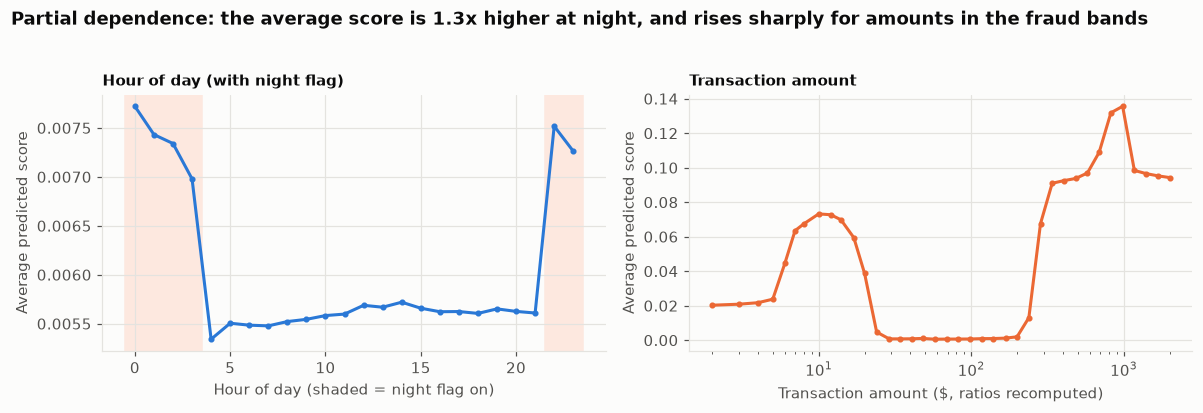

**Takeaway:** A naive partial-dependence plot that varies `hour` alone shows almost no night effect, because the model gets that signal from the separate `is_night` flag. Derived features must be moved together, or the plot describes impossible transactions.

In [9]:
pd_rows = va.sample(4000, random_state=config.SEED)
pd_X = X_of(pd_rows)
# Hour: move hour AND the derived night flag together (is_night is a function of hour)
hour_pd = []
for h in range(24):
    Xh = pd_X.copy(); Xh["hour"] = h; Xh["is_night"] = int(h >= 22 or h < 4)
    hour_pd.append(predict(Xh).mean())
# Amount: move the amount AND recompute the amount-ratio features consistently
base_avg = (pd_rows.amt / pd_rows.amt_to_cust_avg).to_numpy()
base_avg7 = (pd_rows.amt / pd_rows.amt_to_cust_avg_7d).to_numpy()
base_cat = (pd_rows.amt / pd_rows.amt_to_cust_category_avg).to_numpy()
amounts = np.unique(np.round(np.geomspace(2, 2000, 40), 0))
amt_pd = []
for a in amounts:
    Xa = pd_X.copy(); Xa["log_amt"] = np.log1p(a)
    Xa["amt_to_cust_avg"] = np.where(np.isfinite(base_avg), a / base_avg, pd_X["amt_to_cust_avg"])
    Xa["amt_to_cust_avg_7d"] = np.where(np.isfinite(base_avg7), a / base_avg7, pd_X["amt_to_cust_avg_7d"])
    Xa["amt_to_cust_category_avg"] = np.where(np.isfinite(base_cat), a / base_cat, pd_X["amt_to_cust_category_avg"])
    amt_pd.append(predict(Xa).mean())
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(range(24), hour_pd, color=plotting.BLUE, marker="o", ms=3)
axes[0].axvspan(-0.5, 3.5, color="#fde8df", zorder=0); axes[0].axvspan(21.5, 23.5, color="#fde8df", zorder=0)
axes[0].set_xlabel("Hour of day (shaded = night flag on)"); axes[0].set_ylabel("Average predicted score")
axes[0].set_title("Hour of day (with night flag)", loc="left", fontsize=10)
axes[1].plot(amounts, amt_pd, color=plotting.ORANGE, marker="o", ms=3); axes[1].set_xscale("log")
axes[1].set_xlabel("Transaction amount ($, ratios recomputed)"); axes[1].set_ylabel("Average predicted score")
axes[1].set_title("Transaction amount", loc="left", fontsize=10)
night_ratio = np.mean([hour_pd[h] for h in [22, 23, 0, 1, 2, 3]]) / np.mean([hour_pd[h] for h in range(4, 22)])
fig.suptitle(f"Partial dependence: the average score is {night_ratio:.1f}x higher at night, and rises sharply for amounts in the fraud bands",
             x=0.01, ha="left", fontweight="bold", y=1.03)
plotting.save(fig, "partial_dependence"); plt.show()
takeaway("A naive partial-dependence plot that varies `hour` alone shows almost no night effect, because the model gets that signal from "
         "the separate `is_night` flag. Derived features must be moved together, or the plot describes impossible transactions.")

## 5. Segment-level error analysis (test, recommended threshold)

Where does the model under-perform? Recall shows *which frauds we miss*. Precision shows *where analysts waste time*. Segments with few frauds get wide uncertainty, so the fraud count is always shown next to the rate.

In [10]:
te_seg = te.copy()
te_seg["alert"] = te_seg.score_LightGBM >= T_COST
te_seg["amount_band"] = pd.cut(te_seg.amt, [0, 10, 50, 100, 250, 500, 1000, np.inf], right=False,
                               labels=["<$10", "$10-49", "$50-99", "$100-249", "$250-499", "$500-999", "$1,000+"])
te_seg["age_band"] = pd.cut(te_seg.cust_age, [0, 25, 35, 50, 65, 200], right=False, labels=["<25", "25-34", "35-49", "50-64", "65+"])
te_seg["region"] = te_seg.state.map(region)

def seg_metrics(d, col):
    g = d.groupby(col, observed=True)
    out = pd.DataFrame({
        "transactions": g.size(), "frauds": g.is_fraud.sum(), "alerts": g.alert.sum(),
        "TP": g.apply(lambda x: (x.alert & (x.is_fraud == 1)).sum(), include_groups=False),
        "FP": g.apply(lambda x: (x.alert & (x.is_fraud == 0)).sum(), include_groups=False),
    })
    out["recall"] = out.TP / out.frauds.replace(0, np.nan)
    out["precision"] = out.TP / out.alerts.replace(0, np.nan)
    out["false_alert_rate_per_10k_legit"] = 1e4 * out.FP / (out.transactions - out.frauds)
    out.insert(0, "segment_type", col)
    return out.reset_index().rename(columns={col: "segment"})

seg = pd.concat([seg_metrics(te_seg, c) for c in ["category", "amount_band", "age_band", "region", "gender"]], ignore_index=True)
seg.to_csv(config.REPORTS / "segment_error_analysis.csv", index=False)
seg[seg.segment_type.isin(["category", "amount_band"])]

,segment,segment_type,transactions,frauds,alerts,TP,FP,recall,precision,false_alert_rate_per_10k_legit
0,entertainment,category,26794,33,84,33,51,1.0000,0.3929,19.0576
1,food_dining,category,25896,30,122,28,94,0.9333,0.2295,36.3411
2,gas_transport,category,37603,103,117,103,14,1.0000,0.8803,3.7333
3,grocery_net,category,13135,25,76,24,52,0.9600,0.3158,39.6644
4,grocery_pos,category,35213,314,320,314,6,1.0000,0.9812,1.7192
5,health_fitness,category,24413,23,60,21,39,0.9130,0.3500,15.9902
6,home,category,34978,36,84,35,49,0.9722,0.4167,14.0232
7,kids_pets,category,32364,36,90,32,58,0.8889,0.3556,17.9411
8,misc_net,category,18365,181,267,178,89,0.9834,0.6667,48.9441
9,misc_pos,category,23051,41,136,38,98,0.9268,0.2794,42.5902


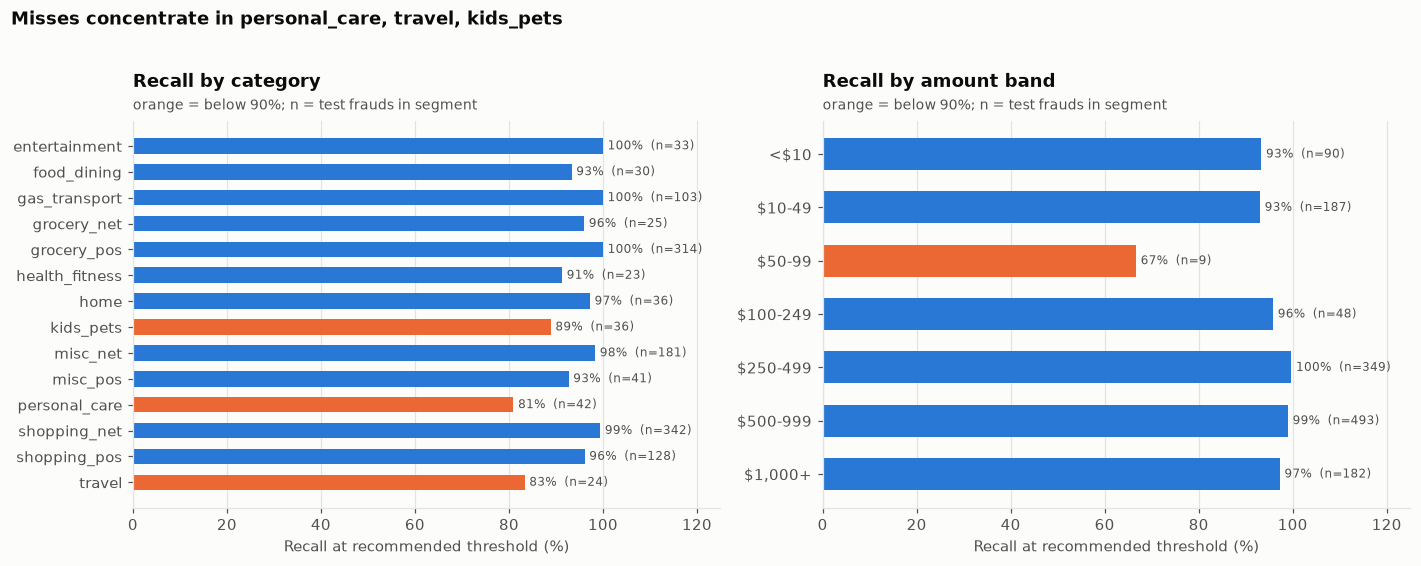

**Takeaway:** The weakest segments with at least 20 test frauds are personal_care (81% recall, n=42), travel (83% recall, n=24), kids_pets (89% recall, n=36). These are low-amount frauds that do not stand out from the customer's normal spend. That is the gap to close with new data (device, merchant risk) rather than a lower threshold.

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, ["category", "amount_band"]):
    s = seg[(seg.segment_type == col) & (seg.frauds > 0)]
    ax.barh(s.segment.astype(str), s.recall * 100, color=[plotting.ORANGE if r < 0.9 else plotting.BLUE for r in s.recall], height=0.6)
    for i, (r, n) in enumerate(zip(s.recall, s.frauds)):
        ax.text(r * 100 + 1, i, f"{r:.0%}  (n={n:,})", va="center", fontsize=8, color=plotting.TEXT_2)
    ax.invert_yaxis(); ax.grid(axis="y", visible=False); ax.set_xlim(0, 125)
    ax.set_xlabel("Recall at recommended threshold (%)")
    plotting.title(ax, f"Recall by {col.replace('_', ' ')}", "orange = below 90%; n = test frauds in segment")
worst = seg[(seg.segment_type.isin(["category", "amount_band"])) & (seg.frauds >= 20)].sort_values("recall").head(3)
fig.suptitle(f"Misses concentrate in {', '.join(worst.segment.astype(str))}", x=0.01, ha="left", fontweight="bold", y=1.02)
plotting.save(fig, "segment_recall"); plt.show()
takeaway(f"The weakest segments with at least 20 test frauds are {', '.join(f'{s} ({r:.0%} recall, n={n})' for s, r, n in zip(worst.segment.astype(str), worst.recall, worst.frauds))}. "
         "These are low-amount frauds that do not stand out from the customer's normal spend. That is the gap to close with new data (device, merchant risk) rather than a lower threshold.")

In [12]:
seg[seg.segment_type.isin(["age_band", "region", "gender"])]

,segment,segment_type,transactions,frauds,alerts,TP,FP,recall,precision,false_alert_rate_per_10k_legit
21,<25,age_band,29977,118,183,118,65,1.0000,0.6448,21.7690
22,25-34,age_band,75639,237,400,227,173,0.9578,0.5675,22.9437
23,35-49,age_band,127678,362,599,349,250,0.9641,0.5826,19.6362
24,50-64,age_band,76511,370,590,367,223,0.9919,0.6220,29.2878
25,65+,age_band,60894,271,460,262,198,0.9668,0.5696,32.6609
26,Midwest,region,104733,376,652,369,283,0.9814,0.5660,27.1184
27,Northeast,region,69879,305,459,299,160,0.9803,0.6514,22.9971
28,South,region,140838,443,765,432,333,0.9752,0.5647,23.7188
29,West,region,55249,234,356,223,133,0.9530,0.6264,24.1752
30,F,gender,203467,695,1209,668,541,0.9612,0.5525,26.6802


## 6. Fairness: demographic features and disparate error rates

**Should age and gender be model features?** The production model **excludes** them:
- They are protected characteristics. Using them to decide whose transactions are held or declined creates disparate-treatment risk and reputational risk. Fair-lending rules such as ECOA/Reg B apply to *credit* decisions. Fraud controls on existing accounts are not credit decisions, but regulators still expect firms to treat customers fairly. **Compliance and legal should review this**; the notebook does not give legal advice.
- The model's job is to detect *behaviour* (unusual spend, velocity, timing), not to profile *who* the customer is.

**Excluding them doesn't guarantee fairness.** Other features can act as proxies, for example spending patterns by category. So we (a) measure error rates by group even though the model never sees age or gender, and (b) run an **ablation** that adds them back, to show what they would contribute.

In [13]:
fair = seg[seg.segment_type.isin(["gender", "age_band"])][["segment_type", "segment", "transactions", "frauds", "recall", "precision", "false_alert_rate_per_10k_legit"]]
fair

,segment_type,segment,transactions,frauds,recall,precision,false_alert_rate_per_10k_legit
21,age_band,<25,29977,118,1.0000,0.6448,21.7690
22,age_band,25-34,75639,237,0.9578,0.5675,22.9437
23,age_band,35-49,127678,362,0.9641,0.5826,19.6362
24,age_band,50-64,76511,370,0.9919,0.6220,29.2878
25,age_band,65+,60894,271,0.9668,0.5696,32.6609
30,gender,F,203467,695,0.9612,0.5525,26.6802
31,gender,M,167232,663,0.9879,0.6403,22.0929


In [14]:
full = features.add_derived(data.load_features()).merge(pd.read_parquet(config.DATA_PROCESSED / "splits.parquet"), on="trans_num")
tr_full = full[full.split == "train"]
va_full = full[full.split == "validation"].set_index("trans_num").loc[va.trans_num].reset_index()
meta = json.loads((config.REPORTS / "model_metadata.json").read_text())
params = dict(num_leaves=meta["lgbm_num_leaves"])
Xd_tr, Xd_va = X_of(tr_full, True), X_of(va_full, True)
if meta["lgbm_treatment"].startswith("SMOTE"):
    Xd_fit, yd_fit = models.resample(Xd_tr, tr_full.is_fraud, "smote")
elif meta["lgbm_treatment"].startswith("Random under"):
    Xd_fit, yd_fit = models.resample(Xd_tr, tr_full.is_fraud, "undersample")
else:
    Xd_fit, yd_fit = Xd_tr, tr_full.is_fraud
    if meta["lgbm_treatment"].startswith("Class"):
        params["scale_pos_weight"] = (tr_full.is_fraud == 0).sum() / (tr_full.is_fraud == 1).sum()
lgb_demo = models.fit_lgbm(Xd_fit, yd_fit, Xd_va, va_full.is_fraud, **params)
s_demo = lgb_demo.predict_proba(Xd_va)[:, 1]
boot = metrics.card_bootstrap_indices(va.cc_num, 200, config.SEED)
bm = metrics.bootstrap_matrix(va.is_fraud, {"without": va.score_LightGBM, "with": s_demo}, boot)
lo, hi = metrics.paired_diff(bm, "with", "without")
ablation = pd.DataFrame({
    "model": ["Production (no demographics)", "Ablation (+ age, gender)"],
    "val_pr_auc": [metrics.pr_auc(va.is_fraud, va.score_LightGBM), metrics.pr_auc(va.is_fraud, s_demo)],
})
ablation["diff_vs_production"] = ablation.val_pr_auc - ablation.val_pr_auc.iloc[0]
ablation.to_csv(config.REPORTS / "demographic_ablation.csv", index=False)
print(f"PR-AUC gain from adding age + gender: {ablation.diff_vs_production.iloc[1]:+.4f} (95% paired card-bootstrap CI {lo:+.4f} to {hi:+.4f})")
ablation

PR-AUC gain from adding age + gender: +0.0079 (95% paired card-bootstrap CI +0.0060 to +0.0102)


,model,val_pr_auc,diff_vs_production
0,Production (no demographics),0.9757,0.0000
1,"Ablation (+ age, gender)",0.9836,0.0079


In [15]:
g = fair[fair.segment_type == "gender"].set_index("segment"); a = fair[fair.segment_type == "age_band"].set_index("segment")
takeaway(f"Without seeing gender, recall is {g.loc['F', 'recall']:.0%} (F) vs {g.loc['M', 'recall']:.0%} (M), and the false-alert rate per 10k legitimate "
         f"transactions is {g.loc['F', 'false_alert_rate_per_10k_legit']:.1f} vs {g.loc['M', 'false_alert_rate_per_10k_legit']:.1f}. Across age bands the false-alert rate ranges "
         f"{a.false_alert_rate_per_10k_legit.min():.1f}-{a.false_alert_rate_per_10k_legit.max():.1f} per 10k. Adding age and gender changes validation PR-AUC by "
         f"{ablation.diff_vs_production.iloc[1]:+.4f} (CI {lo:+.4f} to {hi:+.4f}). "
         + ("That gain is too small to justify the fairness and regulatory risk, so they stay out." if hi < 0.01 else
            "There is a measurable gain. Whether it justifies the fairness and regulatory risk is a decision for model risk and compliance, not the data scientist alone."))

**Takeaway:** Without seeing gender, recall is 96% (F) vs 99% (M), and the false-alert rate per 10k legitimate transactions is 26.7 vs 22.1. Across age bands the false-alert rate ranges 19.6-32.7 per 10k. Adding age and gender changes validation PR-AUC by +0.0079 (CI +0.0060 to +0.0102). There is a measurable gain. Whether it justifies the fairness and regulatory risk is a decision for model risk and compliance, not the data scientist alone.

## 7. Alert triage: from score to queue

Scores are mapped to four operational bands, with cut-offs set on **validation**:

| Band | Rule (validation) | Action |
|---|---|---|
| **Auto-hold** | Precision of everything above the cut-off ≥ 95% | Hold the transaction; contact the cardholder through a registered channel to confirm |
| **Priority review** | Cumulative precision ≥ 80% (below auto-hold) | Analyst review, same-day SLA, reviewed first |
| **Standard review** | Down to the cost-minimising threshold | Analyst review, within 24h |
| **Monitor only** | Down to the capacity-fill threshold (≤100 alerts/day) | No alert. Logged for look-back rules and drift analysis, and reviewed only when the queue has spare capacity |
| No action | Below that | Approve |

Auto-hold creates customer friction, so its cut-off needs very high precision.

In [16]:
cut = {
    "hold": triage.lowest_threshold_with_precision(va.is_fraud, va.score_LightGBM, 0.95),
    "review": triage.lowest_threshold_with_precision(va.is_fraud, va.score_LightGBM, 0.80),
    "standard": T_COST,
    "monitor": decision["thresholds"]["Capacity-constrained (fill 100/day)"],
}
assert cut["hold"] >= cut["review"] >= cut["standard"] >= cut["monitor"], cut
(config.REPORTS / "triage_bands.json").write_text(json.dumps(cut, indent=2))
bands = []
for name, d in [("validation", va), ("test", te)]:
    d = d.assign(band=triage.assign_band(d.score_LightGBM, cut))
    b = triage.band_table(d, "band", DAYS[name]); b.insert(0, "split", name); bands.append(b)
bands = pd.concat(bands)
bands.to_csv(config.REPORTS / "triage_band_table.csv")
bands.reset_index().to_csv(config.DASHBOARD_DATA / "triage_band_table.csv", index=False)
print({k: round(v, 5) for k, v in cut.items()})
bands

{'hold': 0.24362, 'review': 0.03403, 'standard': 0.00845, 'monitor': 0.00017}


,split,transactions,per_day,frauds,fraud_rate_in_band,fraud_usd,share_of_all_fraud
band,,,,,,,
Auto-hold,validation,1843,13.1643,1751,0.9501,"946,415.9300",0.9182
Priority review,validation,455,3.2500,88,0.1934,"29,862.6500",0.0461
Standard review,validation,671,4.7929,32,0.0477,"9,719.8900",0.0168
Monitor only,validation,11028,78.7714,33,0.0030,"4,960.2700",0.0173
No action,validation,357008,"2,550.0571",3,0.0000,33.5300,0.0016
Auto-hold,test,1302,10.0930,1232,0.9462,"693,965.8600",0.9072
Priority review,test,387,3.0000,73,0.1886,"26,590.0900",0.0538
Standard review,test,543,4.2093,18,0.0331,"7,088.1200",0.0133
Monitor only,test,9189,71.2326,27,0.0029,"10,181.2200",0.0199


In [17]:
b = bands[bands.split == "test"]
takeaway(f"On test, auto-hold would catch {b.loc['Auto-hold', 'share_of_all_fraud']:.0%} of all fraud at {b.loc['Auto-hold', 'per_day']:.1f} holds/day "
         f"with {b.loc['Auto-hold', 'fraud_rate_in_band']:.0%} precision. Priority plus standard review adds {b.loc['Priority review', 'per_day'] + b.loc['Standard review', 'per_day']:.1f} "
         f"reviews/day and {b.loc['Priority review', 'share_of_all_fraud'] + b.loc['Standard review', 'share_of_all_fraud']:.0%} of fraud. The monitor-only band holds "
         f"{b.loc['Monitor only', 'share_of_all_fraud']:.1%} of fraud at a {b.loc['Monitor only', 'fraud_rate_in_band']:.1%} hit rate, which is not worth an analyst's time at \\$5 per review.")

**Takeaway:** On test, auto-hold would catch 91% of all fraud at 10.1 holds/day with 95% precision. Priority plus standard review adds 7.2 reviews/day and 7% of fraud. The monitor-only band holds 2.0% of fraud at a 0.3% hit rate, which is not worth an analyst's time at \$5 per review.

### Alert queue for the dashboard

This takes the top test alerts with their three strongest SHAP reasons in plain language. The card number is masked to the last 4 digits, and no names or addresses are included.

In [18]:
te_b = te.assign(band=triage.assign_band(te.score_LightGBM, cut))
queue_idx = te_b[te_b.band.isin(["Auto-hold", "Priority review", "Standard review"])].sort_values("ts").index
q_sv_raw, _ = explain.shap_values(LGB, X_te.loc[queue_idx])
q_sv, _ = explain.group_onehot(q_sv_raw, COLS)
reasons = []
for i, row_sv in zip(queue_idx, q_sv):
    drv = explain.top_drivers(row_sv, gcols, explain.display_values(te.loc[i]), k=3)
    reasons.append("; ".join(f"{d.description} = {explain._fmt(d.value)} ({d.direction})" for d in drv.itertuples()))
queue = te_b.loc[queue_idx, ["trans_num", "ts", "cc_num", "category", "amt", "score_LightGBM", "band", "is_fraud"]].copy()
queue["card"] = "**** " + queue.pop("cc_num").astype(str).str[-4:]
queue["top_reasons"] = reasons
queue = queue.rename(columns={"score_LightGBM": "score", "is_fraud": "label_in_hindsight"})
queue.to_csv(config.DASHBOARD_DATA / "alert_queue_test.csv", index=False)
print(f"{len(queue):,} alerts in the test queue")
queue.head(5)

2,232 alerts in the test queue


,trans_num,ts,category,amt,score,band,label_in_hindsight,card,top_reasons
29,b2d1652684ee10e2c9611c03ec89bbad,2020-08-25 00:13:33,grocery_pos,339.6000,0.9999,Auto-hold,1,**** 0264,Transaction amount = $339.60 (raises risk); Me...
44,42e2b5350defa961e440430eaa36791f,2020-08-25 00:21:08,grocery_net,14.3100,0.9638,Auto-hold,1,**** 0264,"Card spend in prior 24h ($) = 2,384.23 (raises..."
52,7c50881f1e25a74e7f9140d4d2be90aa,2020-08-25 00:23:25,shopping_net,"1,028.4100",0.5003,Auto-hold,1,**** 1773,"Transaction amount = $1,028.41 (raises risk); ..."
103,01c40a2b1142bbbca8e0d6e173fe48ab,2020-08-25 00:47:33,grocery_pos,336.6400,0.9999,Auto-hold,1,**** 1773,Transaction amount = $336.64 (raises risk); Me...
148,d46f2154a7fed0dc83b49ce4dbade7b8,2020-08-25 01:03:41,grocery_pos,320.0900,1.0000,Auto-hold,1,**** 0264,Transaction amount = $320.09 (raises risk); Me...


## 8. Sample alert case report

The case is chosen by a fixed rule: the **Priority review** alert on the **latest test day that has one**, the kind of case an analyst would open that morning. The report is generated by `src/case_report.py` from data only and written **as at alert time**. It includes:
- an account-baseline comparison
- an investigation timeline that makes the data gaps explicit
- disposition options with sign-off fields

The dataset label is written to a separate file (`reports/sample_alert_case_outcome.md`) so it cannot influence the case.

In [19]:
from src import case_report
pr = te_b[te_b.band == "Priority review"]
last_day = pr.ts.dt.normalize().max()
case_i = pr[pr.ts.dt.normalize() == last_day].score_LightGBM.idxmax()
c = te.loc[case_i]
c_sv_raw, _ = explain.shap_values(LGB, X_te.loc[[case_i]])
c_sv, _ = explain.group_onehot(c_sv_raw, COLS)
drv = explain.top_drivers(c_sv[0], gcols, explain.display_values(c), k=6)
report, outcome = case_report.build(c, full, te, cut, drv, band="Priority review",
                                   selection_note="Fixed rule: the highest-scoring priority-review alert on the last test day that has one")
(config.REPORTS / "sample_alert_case.md").write_text(report)
(config.REPORTS / "sample_alert_case_outcome.md").write_text(outcome)
display(Markdown(report))

# Sample alert case report

| | |
|---|---|
| **Case ID** | cc49b7e7ddc2… |
| **Referral source** | Automated model alert: fraud score **0.185**, band **Priority review** (band range 0.034–0.244) |
| **Alert date/time** | 2020-12-31 03:21:50 |
| **How this case was selected** | Fixed rule: the highest-scoring priority-review alert on the last test day that has one |
| **Card** | **** 2231 (first seen in data 2019-01-01) |
| **Assigned analyst (L1)** | ____________ |
| **L2 / senior analyst** | ____________ |

*Scope: facts are taken from the Sparkov synthetic dataset and the model output only. Service levels, band actions and the 60-day label-maturity rule are **workflow assumptions** (see `fraud_triage_workflow.md`), not facts from the data. The section headings follow the project brief; the referral block, baseline comparison, investigation timeline and disposition options follow public financial-crime investigation frameworks (see README, "How ClaudeFinanceLab was used").*

---

## 1. Observed facts (as at alert time)

**Transaction under review**

| Field | Value |
|---|---|
| Date/time | 2020-12-31 03:21:50 |
| Merchant | Langworth, Boehm and Gulgowski |
| Merchant category | shopping_net |
| Amount | $965.86 |
| Card's average transaction before this one (all history since 2019-01-01) | $64.67 over 1,458 transactions (14.9x) |
| Card transactions in the rolling prior 1h / 24h | 1 / 4 |
| Card spend in the rolling prior 24h | $333.63 |
| Time since card's previous transaction | 5 minutes |
| First transaction at this merchant for this card? | No. 1 prior transaction(s) at this merchant, most recently 2020-03-23 ($7.32) |
| Distinct merchants used by the card (all history) | 575 |
| Distance from cardholder's home location to merchant location | 98 km |
| Model alerts on this card in the prior 30 days | 0 |
| Confirmed fraud on this card with labels older than 60 days (known at alert time) | 8 transaction(s) labelled fraud, 2019-07-05 to 2019-07-06 (total $5,362.37) |

**Account baseline vs this activity**

| Measure | Card baseline (prior 90 days) | This alert | Comparison |
|---|---|---|---|
| Transaction amount | median $51.96, 95th percentile $179.96 | $965.86 | 18.6x the median |
| Share of transactions at night (22:00-04:00) | 28% | night | night activity is common for this card (>= 20%) |
| Share of transactions in 'shopping_net' | 3% (6 transactions) | shopping_net | category used before in this window |
| Largest single transaction | $1,158.51 | $965.86 | within prior range |
| Transactions per calendar day (incl. zero-activity days) | median 2, max 9 | 4 in the rolling prior 24h | within prior range |
| Spend per calendar day (incl. zero-activity days) | median $117.31, max $1,158.51 | $333.63 in the rolling prior 24h (+ this $965.86) | above prior daily maximum |

**Card activity in the 48 hours before the alert**

| Time | Category | Amount |
|---|---|---|
| 2020-12-29 04:53 | shopping_pos | $7.14 |
| 2020-12-29 07:40 | shopping_pos | $7.25 |
| 2020-12-29 09:32 | gas_transport | $65.59 |
| 2020-12-29 11:27 | gas_transport | $62.48 |
| 2020-12-29 13:25 | health_fitness | $51.54 |
| 2020-12-29 22:39 | home | $34.22 |
| 2020-12-30 03:56 | grocery_pos | $132.55 |
| 2020-12-30 04:52 | grocery_pos | $78.16 |
| 2020-12-31 01:45 | food_dining | $59.55 |
| 2020-12-31 03:16 | gas_transport | $63.37 |

## 2. Risk indicators (model explanation)

Factors that **raised** the score (SHAP contribution, log-odds):
- **Transaction amount: $965.86** (SHAP +6.07)
- **Amount / customer's historical average: 14.94** (SHAP +2.79)
- **Night-time (22:00-04:00): 1** (SHAP +1.99)
- **Amount / customer's average in this category: 8.46** (SHAP +1.04)

Factors that **lowered** the score:
- **Card spend in prior 1h ($): 63.37** (SHAP -1.13)
- **Merchant category: shopping_net** (SHAP -1.05)

These show what the model reacted to. They are indicators, not evidence that fraud occurred, and not causes.

**Facts consistent with the alert pattern**
- The amount is 14.9x the card's average transaction since 2019-01-01.
- The amount is above the card's 95th-percentile transaction in the prior 90 days ($179.96).
- Spend in the rolling prior 24h plus this transaction ($1,299.49) exceeds the card's largest calendar-day spend in the prior 90 days ($1,158.51).

**Facts that do not fit the alert pattern**
- The card's largest transaction in the prior 90 days ($1,158.51) exceeds this amount.
- 6 earlier transaction(s) on this card since 2019-01-01 were larger than this one.
- The card has 73 earlier 'shopping_net' transactions (largest $1,079.44).
- The card has used this merchant before (1 time(s); most recently 2020-03-23, $7.32).
- Night-time activity is common for this card (28% of prior-90-day transactions; this report treats 20% or more as common), although the model scores night-time as higher risk.

**Other relevant history (neutral)**
- The card has confirmed fraud in its history (8 transactions, 2019-07-05 to 2019-07-06). This is relevant context, not evidence about this transaction.
- The same card number was used 1,116 more times after that fraud. A compromised card would normally be reissued, so this is likely a quirk of the synthetic data: the history may describe the customer rather than one physical card.

## 3. Data gaps: investigation timeline

| Step | Source | Status | Finding |
|---|---|---|---|
| Transaction record reviewed | Transaction data | Completed | See section 1 |
| Card history (all history, 90-day baseline, prior 48h) reviewed | Transaction data | Completed | See section 1 |
| Model score and explanation reviewed | Fraud model (LightGBM, SHAP) | Completed | See section 2 |
| Prior model alerts on the card (30 days) | Model scores | Completed | No prior model alerts in the 30 days before this alert |
| Prior confirmed fraud on the card | Fraud labels older than 60 days | Completed | 8 transaction(s) labelled fraud, 2019-07-05 to 2019-07-06 (total $5,362.37) |
| Cardholder contact | Customer channel | **Not available** | Not in the dataset. Required before disposition |
| Device, IP address, channel | Digital/auth logs | **Not available** | Card-present vs card-not-present cannot be established from this record |
| Authorisation details (CVV / 3-D Secure / POS entry mode) | Authorisation system | **Not available** | |
| Merchant risk profile (chargeback rate, onboarding date) | Merchant data | **Not available** | |
| Disputes / fraud reported in the last 60 days | Case management | **Not available at alert time** | Labels not yet mature |

The data is synthetic (Sparkov simulator), so merchant names and locations are generated.

## 4. Escalation recommendation

**Route to the L1 priority-review queue (same-day SLA; workflow assumption). The transaction has already been authorised, so the purpose of review is to confirm or clear it quickly and, if fraud is confirmed, block the card before further transactions. Contact the cardholder through a registered channel before disposition.**

The score is driven mainly by transaction amount and amount / customer's historical average (section 2). Section 2 also lists facts that do not fit the alert pattern. The information in this record neither confirms nor rules out fraud.

**Disposition (to be completed by the analyst after contact; categories as in the workflow):**
- [ ] Close: false positive (cardholder confirms the transaction)
- [ ] Close: explanation obtained and documented
- [ ] Refer to L2 / senior analyst (conflicting or insufficient information)
- [ ] Confirmed / suspected fraud (cardholder denies, or cannot be reached and evidence supports fraud): block card, reissue, start chargeback. L2 confirms the fraud; the supervisor signs off the account action; compliance decides on any regulatory reporting

Rationale (analyst): __________________________________________

## 5. Next steps

1. Contact the cardholder through a registered channel (not contact details supplied with the transaction) to confirm or deny the transaction.
2. Review the card's other transactions in the same period (section 1) for the same pattern.
3. Obtain the missing items in section 3 (authorisation details, device data, merchant profile) where source systems hold them.
4. Record the disposition and outcome so the label feeds monitoring and retraining.
5. If fraud is confirmed: block and reissue the card, and review other cards that transacted with Langworth, Boehm and Gulgowski in the same window.

| Sign-off | Role | Name | Date |
|---|---|---|---|
| Analyst | L1: prepares case and disposition | | |
| Reviewer | L2 / senior analyst: required for referrals and fraud confirmations | | |
| Approver | Supervisor: required for account action and compliance referral | | |
